# L14 · Clustering

*Companion notebook for Lecture 14 — Clustering (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Implement K-means (Lloyd's algorithm) from scratch, check it on the lecture's worked example, and see why
   restarts and k-means++ seeding matter.
2. Choose K with the elbow, the silhouette and the BIC of a Gaussian mixture.
3. Build a dendrogram and see how single, complete, average and Ward linkage shape clusters.
4. Implement EM for a Gaussian mixture model (GMM) and check it against scikit-learn.
5. Cluster 2,638 blood cells (PBMC3k) with K-means, Ward, a GMM and Leiden; compare them with ARI/NMI and name
   the clusters with marker genes.

Notation (as on the slides): $n$ samples $\mathbf x_i\in\mathbb R^d$, $K$ clusters with index $k$, centers
$\boldsymbol\mu_k$, hard assignments $z_i\in\{1,\dots,K\}$, objective
$J=\sum_i\|\mathbf x_i-\boldsymbol\mu_{z_i}\|^2$; GMM weights $\pi_k$, covariances $\boldsymbol\Sigma_k$ and
responsibilities $r_{ik}$. (Code numbers clusters from 0.)

In [1]:
import os
# numba (used by UMAP / Scanpy) and PyTorch (imported by course_utils) ship different OpenMP runtimes;
# on macOS the combination can crash the kernel. The 'workqueue' threading layer avoids the conflict.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_moons
from sklearn.metrics import (adjusted_rand_score as ari, normalized_mutual_info_score as nmi, silhouette_score,
                             silhouette_samples)
from course_utils import seed_everything, plot_style, DATA, PALETTE as P

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*n_jobs value.*")          # UMAP: random_state disables parallelism
warnings.filterwarnings("ignore", message="zero-centering a sparse")   # sc.pp.scale densifies (2,638 × 1,838: fine)
rng = seed_everything(0)
plot_style()
T0 = time.time()
GREY, INK = "#9AA5B1", "#1F2933"
KCOL = [P[0], P[1], P[2], P[3], P[4], P[5], "#7F4F24", INK, "#8C96A3", "#B8860B", "#6A3D9A", "#1B9E77",
        "#E7298A", "#66A61E", "#A6761D", "#1F78B4"]

## 1. Datasets

**Simulated 2D data (parts 2–5).** Small Gaussian clouds whose true groups we know, so we can see what each
algorithm does and score it. All are generated in this notebook with fixed seeds (the same generators as the slides).

**PBMC3k (part 6).** Droplet single-cell RNA-seq (10x Genomics): counts of RNA molecules (UMIs) per gene in
individual peripheral blood mononuclear cells of one healthy donor. **One sample = one cell** (2,700 cells ×
32,738 genes before quality control). There is no target: we look for groups of cells (candidate cell types) and name
them afterwards with known marker genes. Clustering is how cell atlases are built, and every new scRNA-seq study
starts with it.

Source: 10x Genomics public data set "3k PBMCs from a healthy donor" (free to use), loaded with
`scanpy.datasets.pbmc3k()` (Wolf et al., *Genome Biology* 2018; technology: Zheng et al., *Nature Communications*
2017). The file (≈ 6 MB) is cached in `applications/data/`. Preprocessing is identical to the L15 notebook, so the
numbers match between the two lectures.

## 2. K-means from scratch

Lloyd's algorithm alternates two steps, each of which can only lower $J$:
**assign** $z_i \leftarrow \arg\min_k\|\mathbf x_i-\boldsymbol\mu_k\|^2$, then **update**
$\boldsymbol\mu_k \leftarrow$ mean of the points with $z_i=k$. It stops when the centers no longer move.

In [2]:
def assign(X, mu):
    """Nearest-center assignment; returns z and the objective J."""
    d2 = ((X[:, None, :] - mu[None]) ** 2).sum(-1)
    return d2.argmin(1), d2.min(1).sum()


def update(X, z, mu_old):
    """Each center moves to the mean of its points (an empty cluster keeps its old center)."""
    mu = mu_old.copy()
    for k in range(len(mu)):
        if (z == k).any():
            mu[k] = X[z == k].mean(0)
    return mu


def kmeans_trace(X, mu0, iters=20):
    """Lloyd's algorithm; one entry per iteration: (mu, z, J after assign, new mu, J after update)."""
    mu, out = mu0.copy(), []
    for _ in range(iters):
        z, J = assign(X, mu)
        mu_new = update(X, z, mu)
        out.append((mu.copy(), z.copy(), J, mu_new.copy(), ((X - mu_new[z]) ** 2).sum()))
        if np.allclose(mu_new, mu):
            break
        mu = mu_new
    return out


def init_centers(X, K, how, rng):
    """'random' data points, 'farthest' point, or 'kmeans++' (next center with probability ∝ D(x)²)."""
    n = len(X)
    if how == "random":
        return X[rng.choice(n, K, replace=False)].copy()
    C = [X[rng.integers(n)]]
    for _ in range(K - 1):
        d2 = ((X[:, None, :] - np.array(C)[None]) ** 2).sum(-1).min(1)
        C.append(X[d2.argmax()] if how == "farthest" else X[rng.choice(n, p=d2 / d2.sum())])
    return np.array(C)


def kmeans(X, K, init="random", rng=None, iters=100):
    rng = rng or np.random.default_rng()
    mu = init_centers(X, K, init, rng)
    for _ in range(iters):
        z, _ = assign(X, mu)
        mu_new = update(X, z, mu)
        if np.allclose(mu_new, mu):
            break
        mu = mu_new
    z, J = assign(X, mu)
    return mu, z, J

**The worked example from the slides.** Expression of one gene in six cells, $K=2$, initial centers 1 and 4.

In [3]:
x6 = np.array([1, 2, 4, 7, 8, 10], float)[:, None]
tr = kmeans_trace(x6, np.array([[1.0], [4.0]]))
grp = lambda z, k: "{" + ", ".join(f"{v:g}" for v in x6[z == k, 0]) + "}"
print(pd.DataFrame([{"iteration": t + 1, "clusters": f"{grp(z, 0)} | {grp(z, 1)}", "J after assign": round(J, 2),
                     "new centers": f"{m[0, 0]:.2f}, {m[1, 0]:.2f}", "J after update": round(Ju, 2)}
                    for t, (_, z, J, m, Ju) in enumerate(tr)]).to_string(index=False))
print(f"converged in iteration {len(tr)} (assignments and centers unchanged)")

 iteration               clusters  J after assign new centers  J after update
         1 {1, 2} | {4, 7, 8, 10}           62.00  1.50, 7.25           19.25
         2 {1, 2, 4} | {7, 8, 10}           14.94  2.33, 8.33            9.33
         3 {1, 2, 4} | {7, 8, 10}            9.33  2.33, 8.33            9.33
converged in iteration 3 (assignments and centers unchanged)


$J$: 62 → 19.25 (update) → 14.94 (cell 4 switches to the left cluster) → 9.33, then nothing changes.

**Three clusters in 2D from a deliberately poor start** (all three centers close together).

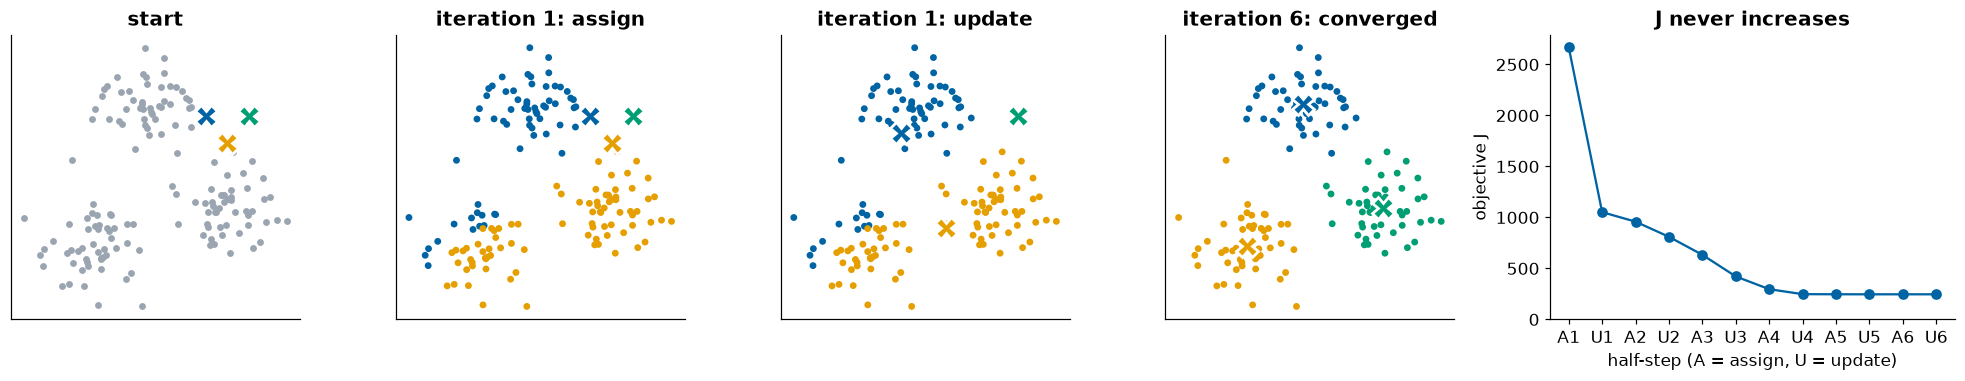

converged in 6 iterations; J after each half-step: 2670, 1051, 958, 810, 633, 421, 296, 247, 246, 246, 246, 246


In [4]:
def blobs(seed=3):
    r = np.random.default_rng(seed)
    C = np.array([[0, 0], [5, 1], [2, 5]], float)
    return np.vstack([r.normal(c, 0.9, (50, 2)) for c in C]), np.repeat([0, 1, 2], 50)


def centers(ax, mu, cols=None, ms=14):
    for k, m in enumerate(mu):
        ax.plot(*m, marker="X", ms=ms, color=(cols or KCOL)[k % len(KCOL)], mec="white", mew=1.8, zorder=5)


Xb, _ = blobs()
tr = kmeans_trace(Xb, np.array([[4.2, 4.6], [5.0, 3.6], [5.8, 4.6]]))
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), gridspec_kw=dict(width_ratios=[1, 1, 1, 1, 1.4]))
panels = [("start", None, tr[0][0]), ("iteration 1: assign", tr[0][1], tr[0][0]),
          ("iteration 1: update", tr[0][1], tr[0][3]), ]
for ax, (ttl, z, mu) in zip(axes, panels + [(f"iteration {len(tr)}: converged", tr[-1][1], tr[-1][3])]):
    ax.scatter(*Xb.T, s=12, c=GREY if z is None else [KCOL[k] for k in z])
    centers(ax, mu)
    ax.set(title=ttl, xticks=[], yticks=[])
vals = [v for st in tr for v in (st[2], st[4])]
axes[4].plot(vals, "o-")
axes[4].set_xticks(range(len(vals)), [f"{s}{t + 1}" for t in range(len(tr)) for s in "AU"])
axes[4].set(xlabel="half-step (A = assign, U = update)", ylabel="objective J", title="J never increases", ylim=(0, None))
plt.tight_layout(); plt.show()
print(f"converged in {len(tr)} iterations; J after each half-step:", ", ".join(f"{v:.0f}" for v in vals))

### Restarts and initialization
$J$ is non-convex: Lloyd's algorithm stops at a **local** minimum that depends on the start. Test: nine Gaussian
clusters on a 3 × 3 grid (40 points each, SD 1, spacing 5), $K=9$, 300 runs per seeding method, with and without
three far outliers. A run "finds the best solution" if its $J$ is within 0.1% of the best known $J$
(scikit-learn with 300 k-means++ restarts).

In [5]:
def grid_blobs(seed=0, outliers=False):
    r = np.random.default_rng(seed)
    C = np.array([[i * 5, j * 5] for i in range(3) for j in range(3)], float)
    X = np.vstack([r.normal(c, 1.0, (40, 2)) for c in C])
    return np.vstack([X, [[22, -6], [-9, 17], [21, 19]]]) if outliers else X


t = time.time()
R = {}
for tag, X in (("clean", grid_blobs()), ("+ 3 outliers", grid_blobs(outliers=True))):
    R[tag, "best"] = KMeans(9, n_init=300, random_state=0).fit(X).inertia_
    r = np.random.default_rng(1)
    for how in ("random", "farthest", "kmeans++"):
        R[tag, how] = np.array([kmeans(X, 9, how, r)[2] for _ in range(300)])
tab = pd.DataFrame({tag: {how: f"{100 * (R[tag, how] < 1.001 * R[tag, 'best']).mean():.0f}%  (median J {np.median(R[tag, how]):.0f})"
                          for how in ("random", "farthest", "kmeans++")} for tag in ("clean", "+ 3 outliers")})
print("runs reaching the best J (of 300):"); print(tab)
print(f"best known J: clean {R['clean', 'best']:.0f}, with outliers {R['+ 3 outliers', 'best']:.0f}   "
      f"({time.time() - t:.0f} s)")

runs reaching the best J (of 300):
                         clean          + 3 outliers
random    28%  (median J 1058)  32%  (median J 1559)
farthest   75%  (median J 673)   0%  (median J 2056)
kmeans++   32%  (median J 673)  16%  (median J 1488)
best known J: clean 672, with outliers 1165   (9 s)


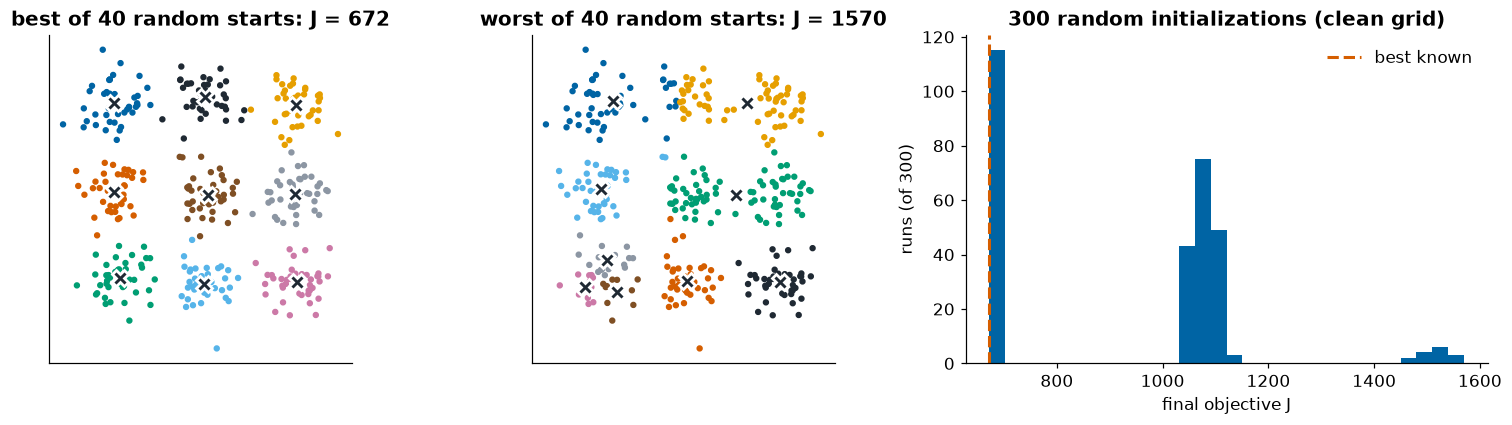

In [6]:
Xg = grid_blobs()
r = np.random.default_rng(1)
sols = [kmeans(Xg, 9, "random", r) for _ in range(40)]
Js = np.array([s[2] for s in sols])
fig, axes = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw=dict(width_ratios=[1, 1, 1.3]))
for ax, i, nm in [(axes[0], Js.argmin(), "best"), (axes[1], Js.argmax(), "worst")]:
    ax.scatter(*Xg.T, s=10, c=[KCOL[k] for k in sols[i][1]])
    centers(ax, sols[i][0], cols=[INK] * 9, ms=11)
    ax.set(title=f"{nm} of 40 random starts: J = {Js[i]:.0f}", xticks=[], yticks=[], aspect="equal")
axes[2].hist(R["clean", "random"], bins=30)
axes[2].axvline(R["clean", "best"], color=P[5], ls="--", lw=2, label="best known")
axes[2].set(xlabel="final objective J", ylabel="runs (of 300)", title="300 random initializations (clean grid)")
axes[2].legend()
plt.tight_layout(); plt.show()

Bad optima merge two true clusters and split another. Farthest-point seeding is excellent on clean data but always
spends centers on the outliers; k-means++ is a compromise with a guarantee
($\mathbb E[J]\le 8(\ln K+2)\,J_{\text{opt}}$ right after seeding). No seeding is perfect: **combine k-means++ with
restarts and keep the lowest $J$.** (scikit-learn's `KMeans` uses k-means++; set `n_init` ≥ 10 explicitly.)

### Scale matters
Two cell groups differ in gene B (log scale, SD ≈ 0.3 within a group); gene A is in raw counts, varies a lot and is
uninformative. K-means uses Euclidean distance, so the feature with the largest spread decides.

In [7]:
r = np.random.default_rng(5)
Xs2 = np.c_[r.normal(500, 150, 300), np.r_[r.normal(1.0, 0.3, 150), r.normal(3.0, 0.3, 150)]]
gs2 = np.repeat([0, 1], 150)
Xs2z = (Xs2 - Xs2.mean(0)) / Xs2.std(0)
for nm, Z in (("raw units", Xs2), ("standardized", Xs2z)):
    z = KMeans(2, n_init=10, random_state=0).fit_predict(Z)
    print(f"K-means on {nm:12s}: ARI vs truth {max(ari(gs2, z), 0.0):.2f}")
print("feature SDs (raw):", Xs2.std(0).round(1))

K-means on raw units   : ARI vs truth 0.00
K-means on standardized: ARI vs truth 1.00
feature SDs (raw): [143.9   1. ]


ARI (adjusted Rand index, part 5) = 1 for perfect agreement and ≈ 0 for chance. This is why the single-cell pipeline
log-transforms and scales genes before clustering.

## 3. Choosing K
$J$ always falls as $K$ grows ($J=0$ at $K=n$), so it cannot choose $K$ by itself. Three criteria on five simulated
clusters (60 points each): the elbow of $J$, the mean **silhouette**
$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}$ ($a$ = mean distance to its own cluster, $b$ = to the nearest other
cluster), and the **BIC** $=-2\log p(\mathbf X\mid\hat{\boldsymbol\theta})+p\log n$ of a spherical GMM.

silhouette from scratch vs scikit-learn (K = 5): max |difference| = 1.9e-15


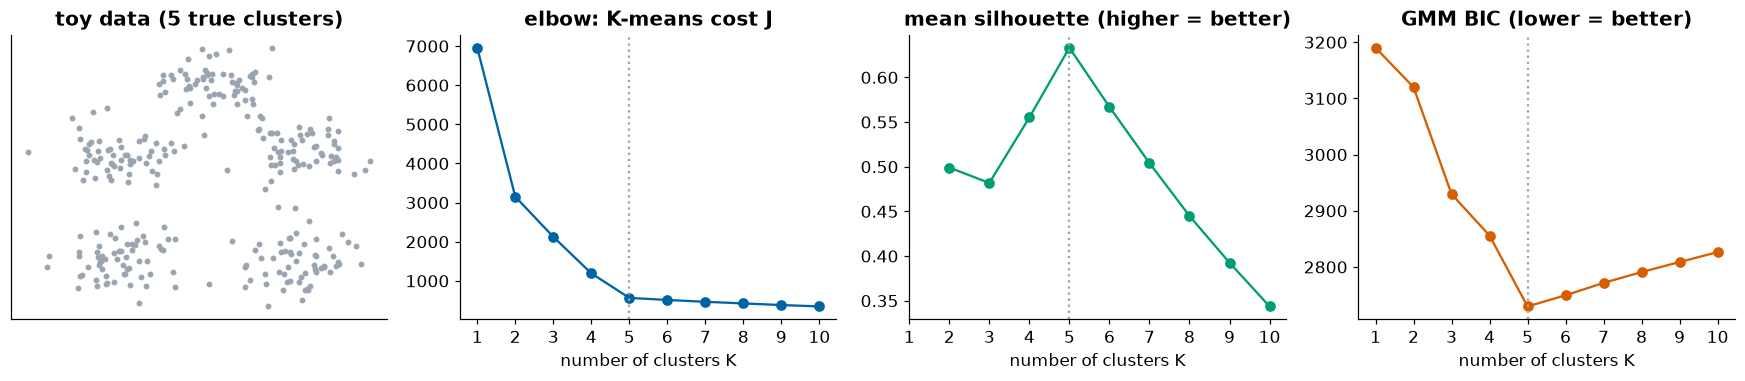

silhouette picks K = 5, BIC picks K = 5


In [8]:
def many_blobs(seed=0):
    r = np.random.default_rng(seed)
    C = np.array([[0, 0], [6, 0], [0, 6], [6, 6], [3, 10]], float)
    return np.vstack([r.normal(c, 1.0, (60, 2)) for c in C]), np.repeat(np.arange(5), 60)


def silhouette_scratch(X, z):
    D = np.sqrt(((X[:, None] - X[None]) ** 2).sum(-1))
    s = np.zeros(len(X))
    for i in range(len(X)):
        own = (z == z[i]); own[i] = False
        if not own.any():
            continue                                    # singleton cluster: s(i) = 0 by convention
        a = D[i, own].mean()
        b = min(D[i, z == k].mean() for k in np.unique(z) if k != z[i])
        s[i] = (b - a) / max(a, b)
    return s


X5, g5 = many_blobs()
Ks = np.arange(1, 11)
J5, sil5, bic5 = [], [], []
for K in Ks:
    km = KMeans(K, n_init=20, random_state=0).fit(X5)
    J5.append(km.inertia_)
    sil5.append(silhouette_score(X5, km.labels_) if K > 1 else np.nan)
    bic5.append(GaussianMixture(K, covariance_type="spherical", n_init=5, random_state=0).fit(X5).bic(X5))
z5 = KMeans(5, n_init=20, random_state=0).fit_predict(X5)
print("silhouette from scratch vs scikit-learn (K = 5): max |difference| =",
      f"{np.abs(silhouette_scratch(X5, z5) - silhouette_samples(X5, z5)).max():.1e}")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
axes[0].scatter(*X5.T, s=8, color=GREY); axes[0].set(title="toy data (5 true clusters)", xticks=[], yticks=[])
axes[1].plot(Ks, J5, "o-"); axes[1].set_title("elbow: K-means cost J")
axes[2].plot(Ks, sil5, "o-", color=P[2]); axes[2].set_title("mean silhouette (higher = better)")
axes[3].plot(Ks, bic5, "o-", color=P[5]); axes[3].set_title("GMM BIC (lower = better)")
for ax in axes[1:]:
    ax.axvline(5, color=GREY, ls=":"); ax.set(xlabel="number of clusters K", xticks=Ks)
plt.tight_layout(); plt.show()
print(f"silhouette picks K = {Ks[1:][np.nanargmax(sil5[1:])]}, BIC picks K = {Ks[np.argmin(bic5)]}")

On real data these criteria rarely agree so neatly (PBMC3k below). Stability across seeds and subsamples, and
above all biological meaning (distinct marker genes), matter as much.

## 4. Hierarchical clustering
Agglomerative clustering starts with every point as its own cluster and repeatedly merges the two closest clusters.
The **dendrogram** records every merge; cutting it at a height gives a flat clustering.

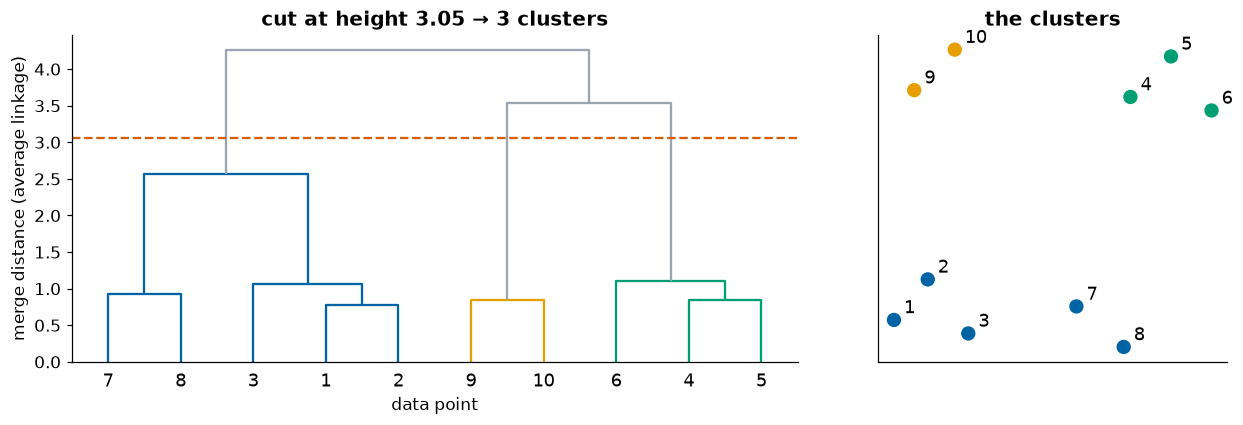

In [9]:
Xa = np.array([[0.5, 1.0], [1.0, 1.6], [1.6, 0.8], [4.0, 4.3], [4.6, 4.9], [5.2, 4.1], [3.2, 1.2], [3.9, 0.6],
               [0.8, 4.4], [1.4, 5.0]])
Za = linkage(Xa, "average")
cut = (Za[-3, 2] + Za[-2, 2]) / 2
lab = fcluster(Za, cut, "distance")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw=dict(width_ratios=[1.5, 1]))
set_link_color_palette(KCOL[:4])
dn = dendrogram(Za, ax=axes[0], color_threshold=cut, above_threshold_color=GREY,
                labels=[str(i + 1) for i in range(10)], leaf_font_size=12)
set_link_color_palette(None)
leafcol = {int(l) - 1: c for l, c in zip(dn["ivl"], dn["leaves_color_list"])}   # same colors in both panels
axes[0].axhline(cut, color=P[5], ls="--")
axes[0].set(ylabel="merge distance (average linkage)", xlabel="data point",
            title=f"cut at height {cut:.2f} → {lab.max()} clusters")
axes[1].scatter(*Xa.T, s=70, c=[leafcol[i] for i in range(10)])
for i, p in enumerate(Xa):
    axes[1].text(p[0] + 0.15, p[1] + 0.1, str(i + 1), fontsize=12)
axes[1].set(title="the clusters", xticks=[], yticks=[], aspect="equal")
plt.tight_layout(); plt.show()

**Four linkages** define the distance between clusters A and B differently: single = closest pair, complete =
farthest pair, average = mean over all pairs, Ward = increase in $J$ when merging
($\frac{|A||B|}{|A|+|B|}\|\boldsymbol\mu_A-\boldsymbol\mu_B\|^2$). Two data sets, two clusters requested each time:

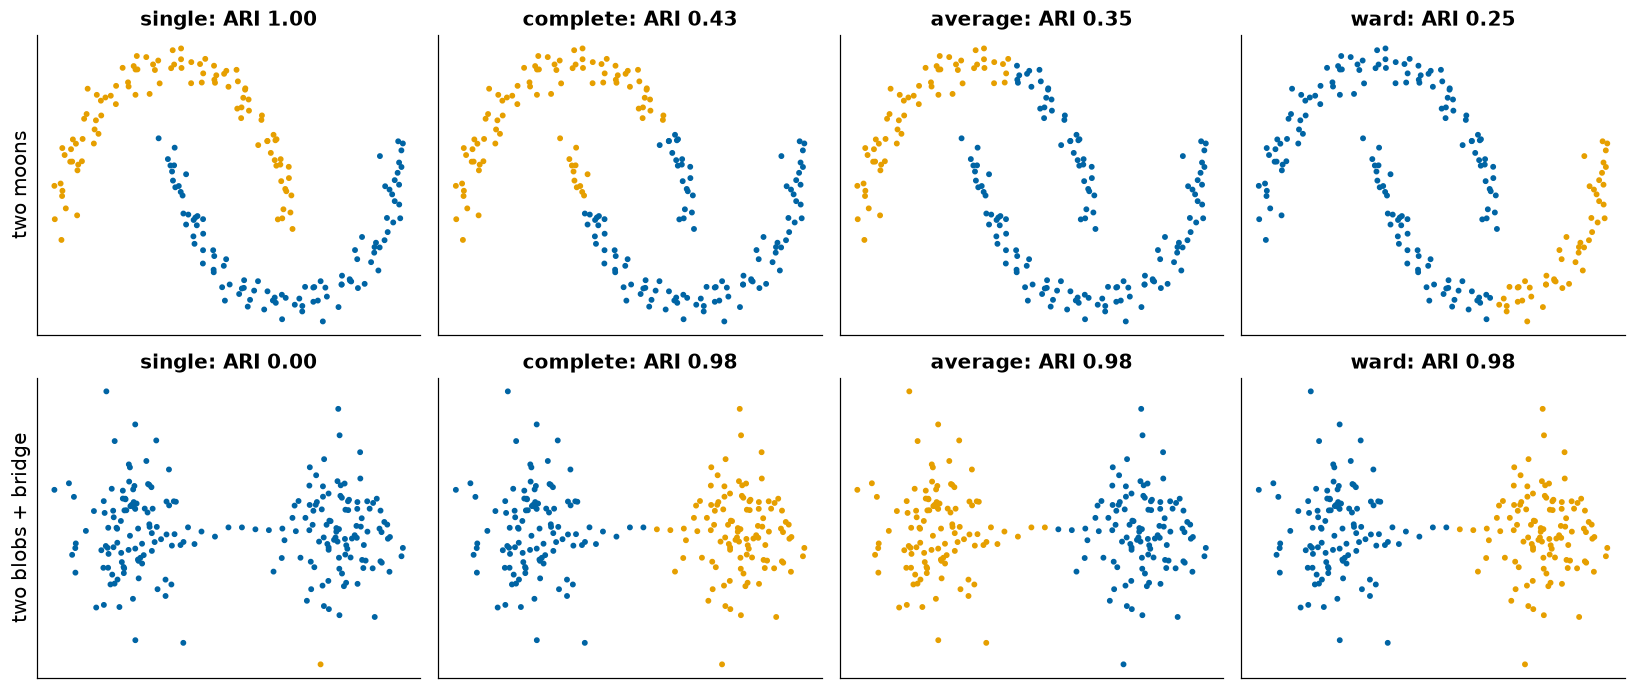

In [10]:
X1, g1 = make_moons(200, noise=0.06, random_state=0)
r = np.random.default_rng(3)
X2 = np.vstack([r.normal([0, 0], 0.5, (100, 2)), r.normal([4, 0], 0.5, (100, 2)),
                np.c_[np.linspace(0.6, 3.4, 12), r.normal(0, 0.05, 12)]])
g2 = np.r_[np.zeros(100), np.ones(100), (np.linspace(0.6, 3.4, 12) > 2)].astype(int)
LINKS = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.4))
for i, (X, g, nm) in enumerate([(X1, g1, "two moons"), (X2, g2, "two blobs + bridge")]):
    for j, lk in enumerate(LINKS):
        z = AgglomerativeClustering(2, linkage=lk).fit_predict(X)
        a = ari(g, z)
        axes[i, j].scatter(*X.T, s=8, c=[KCOL[k] for k in z])
        axes[i, j].set(title=f"{lk}: ARI {abs(a) if abs(a) < 0.005 else a:.2f}", xticks=[], yticks=[])
    axes[i, 0].set_ylabel(nm, fontsize=13)
plt.tight_layout(); plt.show()

Single linkage follows chains (perfect on the moons) but a thin bridge fools it: it splits off one stray point
instead. Complete, average and Ward prefer compact clusters. **The linkage encodes what you believe a cluster is.**

## 5. Gaussian mixtures and EM
A GMM is a generative model: $z_i\sim\text{Categorical}(\boldsymbol\pi)$,
$\mathbf x_i\mid z_i=k\sim\mathcal N(\boldsymbol\mu_k,\boldsymbol\Sigma_k)$. EM alternates

- **E-step:** responsibilities $r_{ik}=\dfrac{\pi_k\mathcal N(\mathbf x_i\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_i\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}$;
- **M-step:** $n_k=\sum_i r_{ik}$, $\pi_k=n_k/n$, $\boldsymbol\mu_k=\frac1{n_k}\sum_i r_{ik}\mathbf x_i$,
  $\boldsymbol\Sigma_k=\frac1{n_k}\sum_i r_{ik}(\mathbf x_i-\boldsymbol\mu_k)(\mathbf x_i-\boldsymbol\mu_k)^\top$
  (plus a tiny ridge $10^{-6}\mathbf I$ so no covariance becomes singular).

The log-likelihood $\ell(\boldsymbol\theta)=\sum_i\log\sum_k\pi_k\mathcal N(\mathbf x_i\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)$ never decreases.

n = 330; log-likelihood / n: -5.64 → -3.26; converged (change < 1e-4) after 21 iterations; ever decreased: False


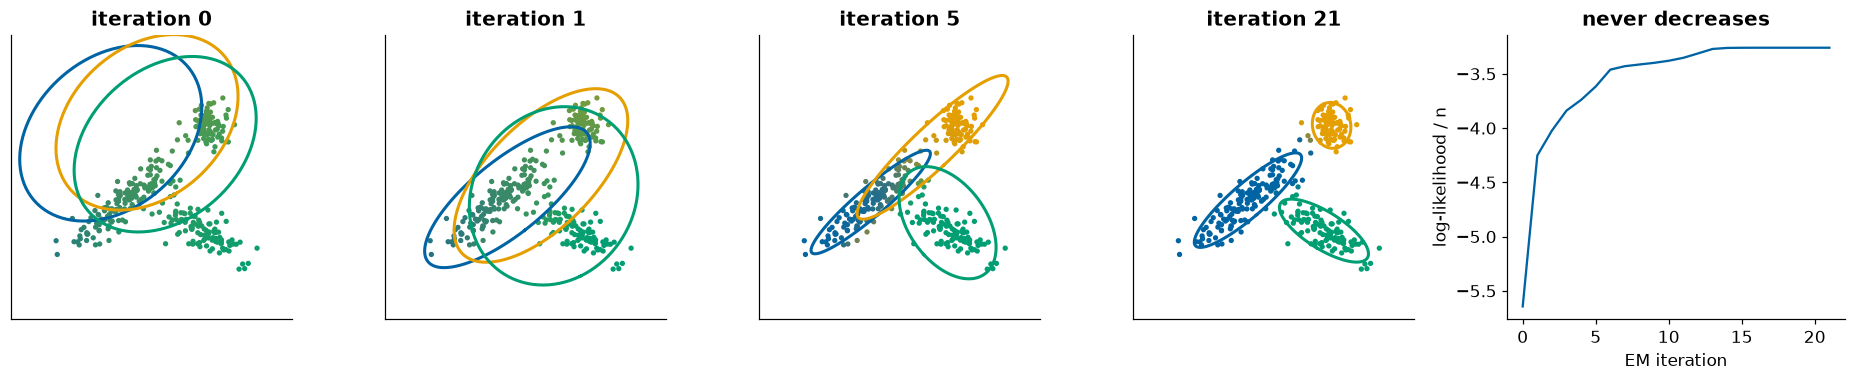

In [11]:
def gauss(X, m, C):
    d = X.shape[1]
    D = X - m
    return np.exp(-0.5 * np.einsum("ij,jk,ik->i", D, np.linalg.inv(C), D)) / np.sqrt((2 * np.pi) ** d * np.linalg.det(C))


def em_gmm(X, mu0, iters=60):
    """EM for a full-covariance GMM. Start: given means, equal weights, every Σ_k = covariance of all data."""
    K, d = mu0.shape
    mu, Sig, pi = mu0.copy(), np.array([np.cov(X.T) for _ in range(K)]), np.full(K, 1 / K)
    hist = []
    for t in range(iters + 1):
        dens = np.stack([pi[k] * gauss(X, mu[k], Sig[k]) for k in range(K)], 1)     # E-step
        r_ = dens / dens.sum(1, keepdims=True)
        hist.append(dict(mu=mu.copy(), Sig=Sig.copy(), pi=pi.copy(), r=r_, ll=np.log(dens.sum(1)).sum()))
        Nk = r_.sum(0)                                                              # M-step
        pi = Nk / len(X)
        mu = (r_.T @ X) / Nk[:, None]
        Sig = np.array([((r_[:, k, None] * (X - mu[k])).T @ (X - mu[k])) / Nk[k] + 1e-6 * np.eye(d) for k in range(K)])
    return hist


r = np.random.default_rng(4)
comps = [([0, 0], [[2.0, 1.2], [1.2, 1.0]], 150), ([4.5, 3.5], [[0.3, 0.0], [0.0, 0.3]], 80),
         ([4.0, -1.5], [[1.2, -0.5], [-0.5, 0.5]], 100)]
Xm = np.vstack([r.multivariate_normal(m, C, n_) for m, C, n_ in comps])
gm = np.repeat([0, 1, 2], [c[2] for c in comps])
mu0 = np.array([[-1.0, 3.0], [1.0, 3.5], [2.0, 2.5]])
hist = em_gmm(Xm, mu0, iters=80)
lls = np.array([h["ll"] for h in hist])
conv = int(np.argmax(np.abs(np.diff(lls)) < 1e-4)) + 1
print(f"n = {len(Xm)}; log-likelihood / n: {lls[0] / len(Xm):.2f} → {lls[conv] / len(Xm):.2f}; "
      f"converged (change < 1e-4) after {conv} iterations; ever decreased: {bool((np.diff(lls) < -1e-9).any())}")


def ellipse(ax, m, C, col, nsd=2.0):
    lam, V = np.linalg.eigh(C)
    t_ = np.linspace(0, 2 * np.pi, 100)
    pts = (V @ (np.sqrt(lam)[:, None] * nsd * np.vstack([np.cos(t_), np.sin(t_)]))).T + m
    ax.plot(pts[:, 0], pts[:, 1], color=col, lw=2)


rgb = np.array([[int(c[i:i + 2], 16) / 255 for i in (1, 3, 5)] for c in KCOL[:3]])
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), gridspec_kw=dict(width_ratios=[1, 1, 1, 1, 1.2]))
for ax, t_ in zip(axes, [0, 1, 5, conv]):
    h = hist[t_]
    ax.scatter(*Xm.T, s=6, c=np.clip(h["r"] @ rgb, 0, 1))
    for k in range(3):
        ellipse(ax, h["mu"][k], h["Sig"][k], KCOL[k])
    ax.set(title=f"iteration {t_}", xticks=[], yticks=[], xlim=(-6.5, 9), ylim=(-5.5, 7.5))
axes[4].plot(lls[:conv + 1] / len(Xm))
axes[4].set(xlabel="EM iteration", ylabel="log-likelihood / n", title="never decreases")
plt.tight_layout(); plt.show()

Point colors mix the component colors by $r_{ik}$; ellipses are 2-SD contours.

**Check against scikit-learn.** Give `GaussianMixture` the same starting parameters (weights, means, and precisions
$\boldsymbol\Sigma_k^{-1}$) and the same ridge (`reg_covar=1e-6`); it runs the same E/M updates.

In [12]:
S0 = np.cov(Xm.T)
sk = GaussianMixture(3, covariance_type="full", weights_init=np.full(3, 1 / 3), means_init=mu0,
                     precisions_init=np.array([np.linalg.inv(S0)] * 3), reg_covar=1e-6, tol=1e-10,
                     max_iter=80).fit(Xm)
h = hist[-1]
print(f"iterations: ours 80, scikit-learn {sk.n_iter_}")
print("max |Δ means|  =", f"{np.abs(sk.means_ - h['mu']).max():.1e}")
print("max |Δ weights|=", f"{np.abs(sk.weights_ - h['pi']).max():.1e}")
print("max |Δ Σ|      =", f"{np.abs(sk.covariances_ - h['Sig']).max():.1e}")
print(f"log-likelihood / n: ours {lls[-1] / len(Xm):.6f}, scikit-learn {sk.score(Xm):.6f}")
print(f"ARI vs the simulated components: {ari(gm, h['r'].argmax(1)):.2f}")

iterations: ours 80, scikit-learn 27
max |Δ means|  = 2.7e-06
max |Δ weights|= 4.2e-07
max |Δ Σ|      = 7.1e-06
log-likelihood / n: ours -3.259962, scikit-learn -3.259962
ARI vs the simulated components: 0.95


**Where K-means fails and a GMM does not.** K-means boundaries are straight lines halfway between centers
(Voronoi cells), and squared error prefers splitting a big cluster to isolating a small one. A full-covariance GMM
learns each cluster's shape and size ($\pi_k$). (K-means is the limit of a GMM with $\boldsymbol\Sigma_k=\sigma^2\mathbf I$,
$\pi_k=1/K$ and $\sigma\to0$, where $r_{ik}$ becomes 0/1.)

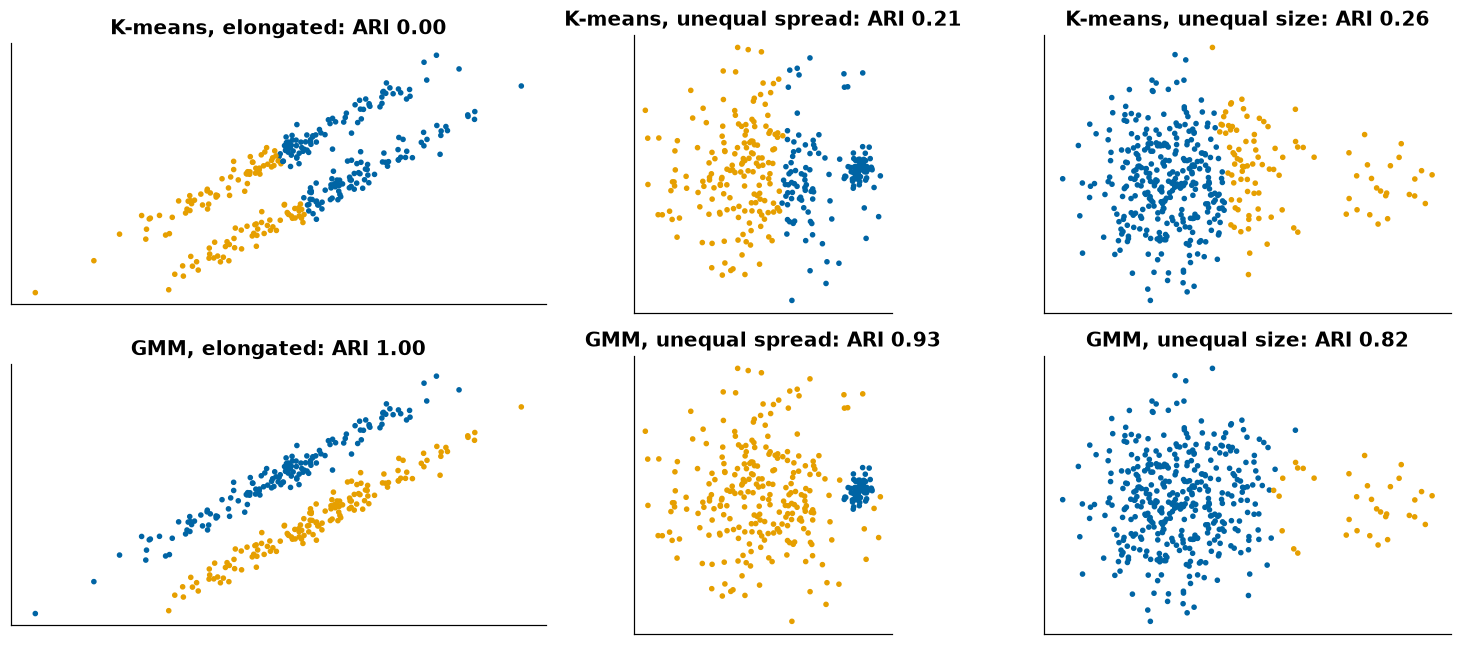

In [13]:
r = np.random.default_rng(7)
A_ = r.normal(0, 1, (300, 2)) * [4.0, 0.35]; A_[:150, 1] += 2.4
th = 0.5; A_ = A_ @ np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]]).T
B_ = np.vstack([r.normal([0, 0], 2.2, (250, 2)), r.normal([4.8, 0], 0.4, (60, 2))])
C_ = np.vstack([r.normal([0, 0], 1.0, (400, 2)), r.normal([4.5, 0], 0.6, (25, 2))])
shapes = [(A_, np.repeat([0, 1], 150), "elongated"), (B_, np.repeat([0, 1], [250, 60]), "unequal spread"),
          (C_, np.repeat([0, 1], [400, 25]), "unequal size")]
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for j, (X, g, nm) in enumerate(shapes):
    zk = KMeans(2, n_init=10, random_state=0).fit_predict(X)
    zg = GaussianMixture(2, covariance_type="full", n_init=10, init_params="random_from_data",
                         random_state=0).fit(X).predict(X)
    for i, (z, mname) in enumerate([(zk, "K-means"), (zg, "GMM")]):
        a = ari(g, z)
        axes[i, j].scatter(*X.T, s=7, c=[KCOL[k] for k in z])
        axes[i, j].set(title=f"{mname}, {nm}: ARI {abs(a) if abs(a) < 0.005 else a:.2f}", xticks=[], yticks=[],
                       aspect="equal")
plt.tight_layout(); plt.show()

**ARI and NMI in one line each.** Both compare two partitions and ignore the cluster *numbers*: ARI counts pairs
of samples on which the partitions agree, corrected for chance; NMI is mutual information divided by mean entropy
(not chance-corrected, so random labels score slightly above 0).

In [14]:
r = np.random.default_rng(6)
Xe = np.vstack([r.normal(c, 0.55, (20, 2)) for c in ([0, 0], [3.2, 0.2], [1.6, 2.7])])
ye = np.repeat([0, 1, 2], 20)
split = ye.copy(); split[(ye == 0) & (Xe[:, 0] < 0)] = 3; split[ye == 2] = 1
rnd = r.integers(0, 3, len(ye))
for nm, z in [("same groups, new numbers", np.array([2, 0, 1])[ye]), ("splits one, merges two", split),
              ("random labels", rnd)]:
    print(f"{nm:26s} ARI {ari(ye, z):5.2f}   NMI {nmi(ye, z):.2f}")

same groups, new numbers   ARI  1.00   NMI 1.00
splits one, merges two     ARI  0.44   NMI 0.65
random labels              ARI  0.02   NMI 0.05


## 6. Application: cell types in PBMC3k

### Exploration and preprocessing
Pipeline (Scanpy PBMC3k tutorial, identical to L15): quality control (keep cells with 200–2,500 detected genes and
< 5% mitochondrial counts; genes seen in ≥ 3 cells) → normalize each cell to 10,000 counts → $\log(1+x)$ → highly
variable genes → scale each gene (clip at 10) → PCA (50 components; we use 40).
The function has a `log1p` switch for the *Try it yourself* section (without the log, the gene selection formula
breaks, so it then reuses the same 1,838 genes).

raw: 2,700 cells × 32,738 genes; 97.4% of entries are 0


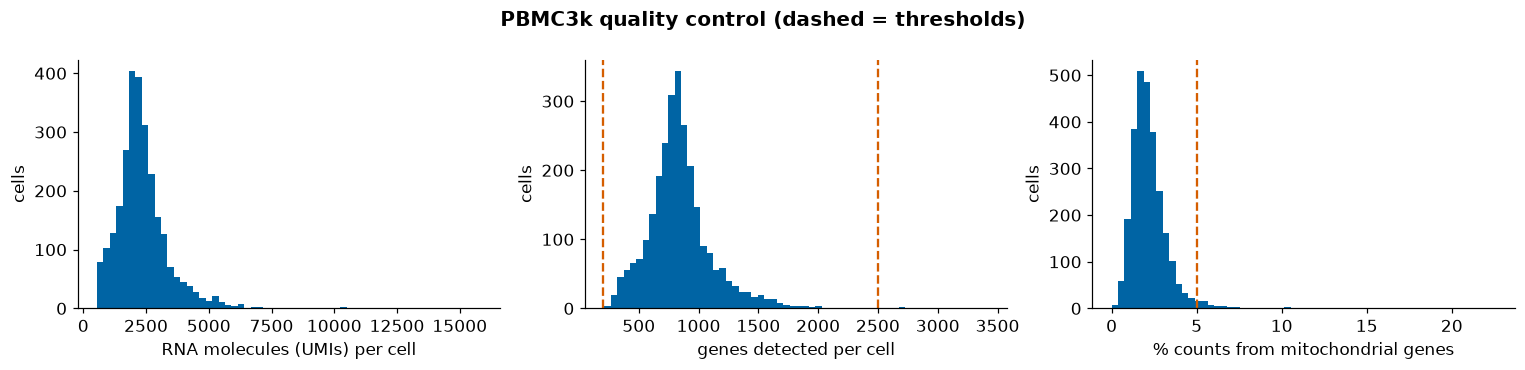

after QC: 2,638 cells; 13,714 genes in ≥ 3 cells; 1,838 highly variable genes (15 s)


In [15]:
import scanpy as sc
from scipy import sparse
sc.settings.datasetdir = DATA
sc.settings.verbosity = 0


def preprocess(log1p=True, genes=None):
    """L15 pipeline. genes: use this gene list instead of selecting highly variable genes."""
    a = sc.datasets.pbmc3k()
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    sc.pp.filter_cells(a, min_genes=200)
    sc.pp.filter_genes(a, min_cells=3)
    a = a[(a.obs.n_genes_by_counts < 2500) & (a.obs.pct_counts_mt < 5)].copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    if log1p:
        sc.pp.log1p(a)
    a.raw = a
    if genes is None:
        sc.pp.highly_variable_genes(a, min_mean=0.0125, max_mean=3, min_disp=0.5)
        genes = a.var_names[a.var.highly_variable]
    a = a[:, genes].copy()
    sc.pp.scale(a, max_value=10)
    sc.tl.pca(a, n_comps=50, svd_solver="arpack", random_state=0)
    return a


raw0 = sc.datasets.pbmc3k()
raw0.var["mt"] = raw0.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(raw0, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
Xr = sparse.csr_matrix(raw0.X)
print(f"raw: {raw0.n_obs:,} cells × {raw0.n_vars:,} genes; {100 * (1 - Xr.nnz / np.prod(raw0.shape)):.1f}% of entries are 0")
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].hist(raw0.obs.total_counts, bins=60); axes[0].set_xlabel("RNA molecules (UMIs) per cell")
axes[1].hist(raw0.obs.n_genes_by_counts, bins=60); axes[1].set_xlabel("genes detected per cell")
axes[2].hist(raw0.obs.pct_counts_mt, bins=60); axes[2].set_xlabel("% counts from mitochondrial genes")
for x_ in (200, 2500):
    axes[1].axvline(x_, color=P[5], ls="--")
axes[2].axvline(5, color=P[5], ls="--")
for ax in axes:
    ax.set_ylabel("cells")
fig.suptitle("PBMC3k quality control (dashed = thresholds)", fontweight="bold")
plt.tight_layout(); plt.show()

t = time.time()
adata = preprocess()
print(f"after QC: {adata.n_obs:,} cells; {adata.raw.n_vars:,} genes in ≥ 3 cells; {adata.n_vars:,} highly variable "
      f"genes ({time.time() - t:.0f} s)")

High mitochondrial fraction marks broken cells that lost cytoplasmic mRNA; very many genes can mean a doublet
(two cells in one droplet).

### Model: Leiden on the kNN graph (the field standard)
Connect each cell to its $k=10$ nearest neighbors in the space of the first 40 PCs, then find **communities**
(many edges inside, few between) with the Leiden algorithm. There is no $K$: the `resolution` sets the granularity.
The three settings below are the ones the *Try it yourself* items change.

In [16]:
RESOLUTION = 1.0   # Leiden resolution
N_PCS = 40         # number of PCs used by every method

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=N_PCS, random_state=0)
sc.tl.leiden(adata, resolution=RESOLUTION, random_state=0, flavor="igraph", n_iterations=2, directed=False)
leiden = adata.obs.leiden.astype(int).values
K = int(leiden.max() + 1)
print(f"Leiden (resolution {RESOLUTION}) → K = {K} clusters; sizes:",
      ", ".join(f"{c}: {n_}" for c, n_ in enumerate(np.bincount(leiden))))

Leiden (resolution 1.0) → K = 9 clusters; sizes: 0: 641, 1: 275, 2: 163, 3: 532, 4: 339, 5: 211, 6: 427, 7: 37, 8: 13


### Marker genes turn cluster numbers into cell types
Annotation rule (same as L15): for each cluster, average each cell type's canonical marker genes (log-normalized
expression), z-score these averages across clusters and pick the highest.

     cell type  cells  mean % mito
0        CD4 T    641          1.8
1        CD8 T    275          2.5
2           NK    163          2.1
3        CD4 T    532          2.0
4            B    339          2.2
5  FCGR3A mono    211          2.4
6    CD14 mono    427          2.3
7           DC     37          2.0
8     Platelet     13          1.9


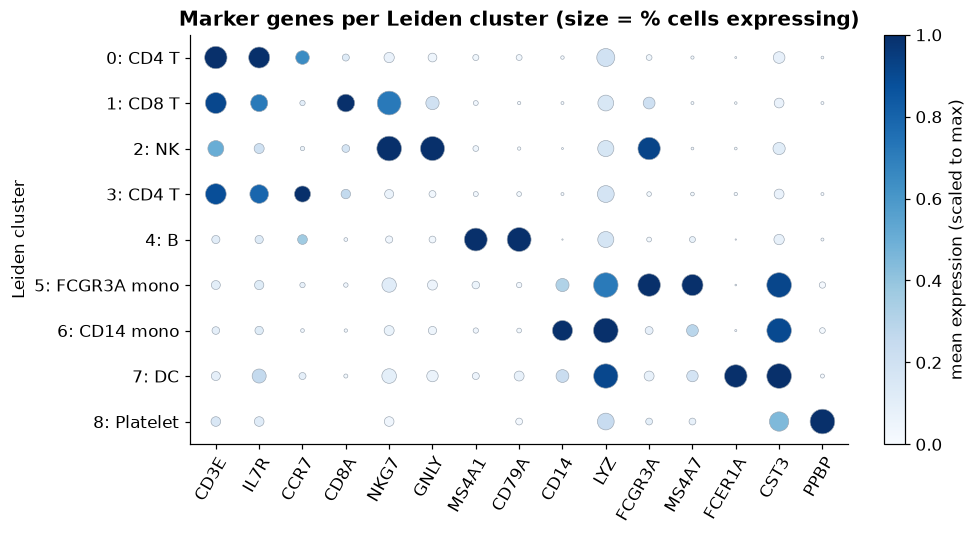

In [17]:
MARKERS = {"CD4 T": ["IL7R", "CCR7"], "CD8 T": ["CD8A", "CD8B"], "NK": ["GNLY", "NKG7"], "B": ["MS4A1", "CD79A"],
           "CD14 mono": ["CD14", "LYZ"], "FCGR3A mono": ["FCGR3A", "MS4A7"], "DC": ["FCER1A", "CST3"],
           "Platelet": ["PPBP"]}
CTYPES = list(MARKERS)
CCOL = dict(zip(CTYPES, [P[0], P[4], P[2], P[1], P[5], P[3], "#7F4F24", INK]))
DOT_GENES = ["CD3E", "IL7R", "CCR7", "CD8A", "NKG7", "GNLY", "MS4A1", "CD79A", "CD14", "LYZ", "FCGR3A", "MS4A7",
             "FCER1A", "CST3", "PPBP"]


def annotate(a, labels):
    R_ = a.raw.to_adata()
    M = pd.DataFrame({ct: np.asarray(R_[:, gs].X.todense()).mean(1) for ct, gs in MARKERS.items()})
    G = M.groupby(labels).mean()
    return ((G - G.mean()) / G.std()).idxmax(axis=1).to_dict()


mapping = annotate(adata, leiden)
ctype = np.array([mapping[c] for c in leiden])
mt_cl = adata.obs.pct_counts_mt.groupby(leiden).mean()
print(pd.DataFrame({"cell type": pd.Series(mapping), "cells": np.bincount(leiden), "mean % mito": mt_cl.round(1)}))

E = np.asarray(adata.raw.to_adata()[:, DOT_GENES].X.todense())
dot_mean = np.array([E[leiden == c].mean(0) for c in range(K)])
dot_frac = np.array([(E[leiden == c] > 0).mean(0) for c in range(K)])
fig, ax = plt.subplots(figsize=(9, 5))
yy, xx = np.meshgrid(np.arange(K), np.arange(len(DOT_GENES)), indexing="ij")
dots = ax.scatter(xx.ravel(), yy.ravel(), s=260 * dot_frac.ravel(), c=(dot_mean / dot_mean.max(0)).ravel(),
                  cmap="Blues", vmin=0, vmax=1, edgecolor=GREY, lw=0.4)
ax.set_xticks(range(len(DOT_GENES)), DOT_GENES, rotation=60, ha="right", rotation_mode="anchor")
ax.set_yticks(range(K), [f"{c}: {mapping[c]}" for c in range(K)])
ax.set(xlim=(-0.6, len(DOT_GENES) - 0.4), ylim=(K - 0.5, -0.5), ylabel="Leiden cluster",
       title="Marker genes per Leiden cluster (size = % cells expressing)")
plt.colorbar(dots, ax=ax, fraction=0.03, label="mean expression (scaled to max)")
plt.tight_layout(); plt.show()

Two clusters are CD4 T cells (the one with high CCR7 is likely naive, the other memory — a finer split than our
marker panel names). CD3E marks all T cells. The tiny PPBP cluster is platelets (13 cells in the default run).
Mean % mitochondrial counts is similar in every cluster, so no cluster is a damaged-cell artifact.

### Four methods on the same 40 PCs
K-means (20 restarts), agglomerative Ward, and a full-covariance GMM, each with Leiden's $K$. The GMM needs a
larger ridge on $\boldsymbol\Sigma_k$ (`reg_covar=1e-3`) and float64 input: 40-dimensional covariances of small
clusters are close to singular.

In [18]:
Xp = adata.obsm["X_pca"][:, :N_PCS].astype(np.float64)
t = time.time()
labs = {"Leiden": leiden,
        "K-means": KMeans(K, n_init=20, random_state=0).fit_predict(Xp),
        "Ward": AgglomerativeClustering(K, linkage="ward").fit_predict(Xp),
        "GMM": GaussianMixture(K, covariance_type="full", reg_covar=1e-3, n_init=3, random_state=0).fit(Xp).predict(Xp)}
print(f"K-means + Ward + GMM: {time.time() - t:.0f} s")
names = list(labs)
ARI = pd.DataFrame([[ari(labs[p], labs[q]) for q in names] for p in names], names, names)
NMI = pd.DataFrame([[nmi(labs[p], labs[q]) for q in names] for p in names], names, names)
print("ARI between methods:"); print(ARI.round(2))
print("\nNMI between methods:"); print(NMI.round(2))
print("\nagainst the marker-based cell-type labels (8 types, derived from Leiden):")
print(pd.DataFrame({"ARI": [ari(ctype, labs[p]) for p in names], "NMI": [nmi(ctype, labs[p]) for p in names],
                    "silhouette (40 PCs)": [silhouette_score(Xp, labs[p]) for p in names]}, index=names).round(3))

K-means + Ward + GMM: 2 s
ARI between methods:
         Leiden  K-means  Ward   GMM
Leiden     1.00     0.74  0.59  0.58
K-means    0.74     1.00  0.59  0.63
Ward       0.59     0.59  1.00  0.63
GMM        0.58     0.63  0.63  1.00

NMI between methods:
         Leiden  K-means  Ward   GMM
Leiden     1.00     0.82  0.78  0.74
K-means    0.82     1.00  0.77  0.77
Ward       0.78     0.77  1.00  0.77
GMM        0.74     0.77  0.77  1.00

against the marker-based cell-type labels (8 types, derived from Leiden):


           ARI    NMI  silhouette (40 PCs)
Leiden   0.711  0.913                0.073
K-means  0.649  0.822                0.079
Ward     0.865  0.848                0.135
GMM      0.641  0.786                0.081


**Reference labels are not ground truth.** Our cell-type labels are names given to *Leiden* clusters, so they
favor Leiden by construction; Ward scores highest against the 8 types because it does not split the CD4 T cells in
two — a difference in resolution, not an error. All silhouettes are low: in blood, some cell types form a continuum.

### Visualization
UMAP of the 40 PCs, for display only (the clusters were computed in PC space). Each method's cluster numbers are
matched to the Leiden clusters with the Hungarian algorithm so that colors are comparable.

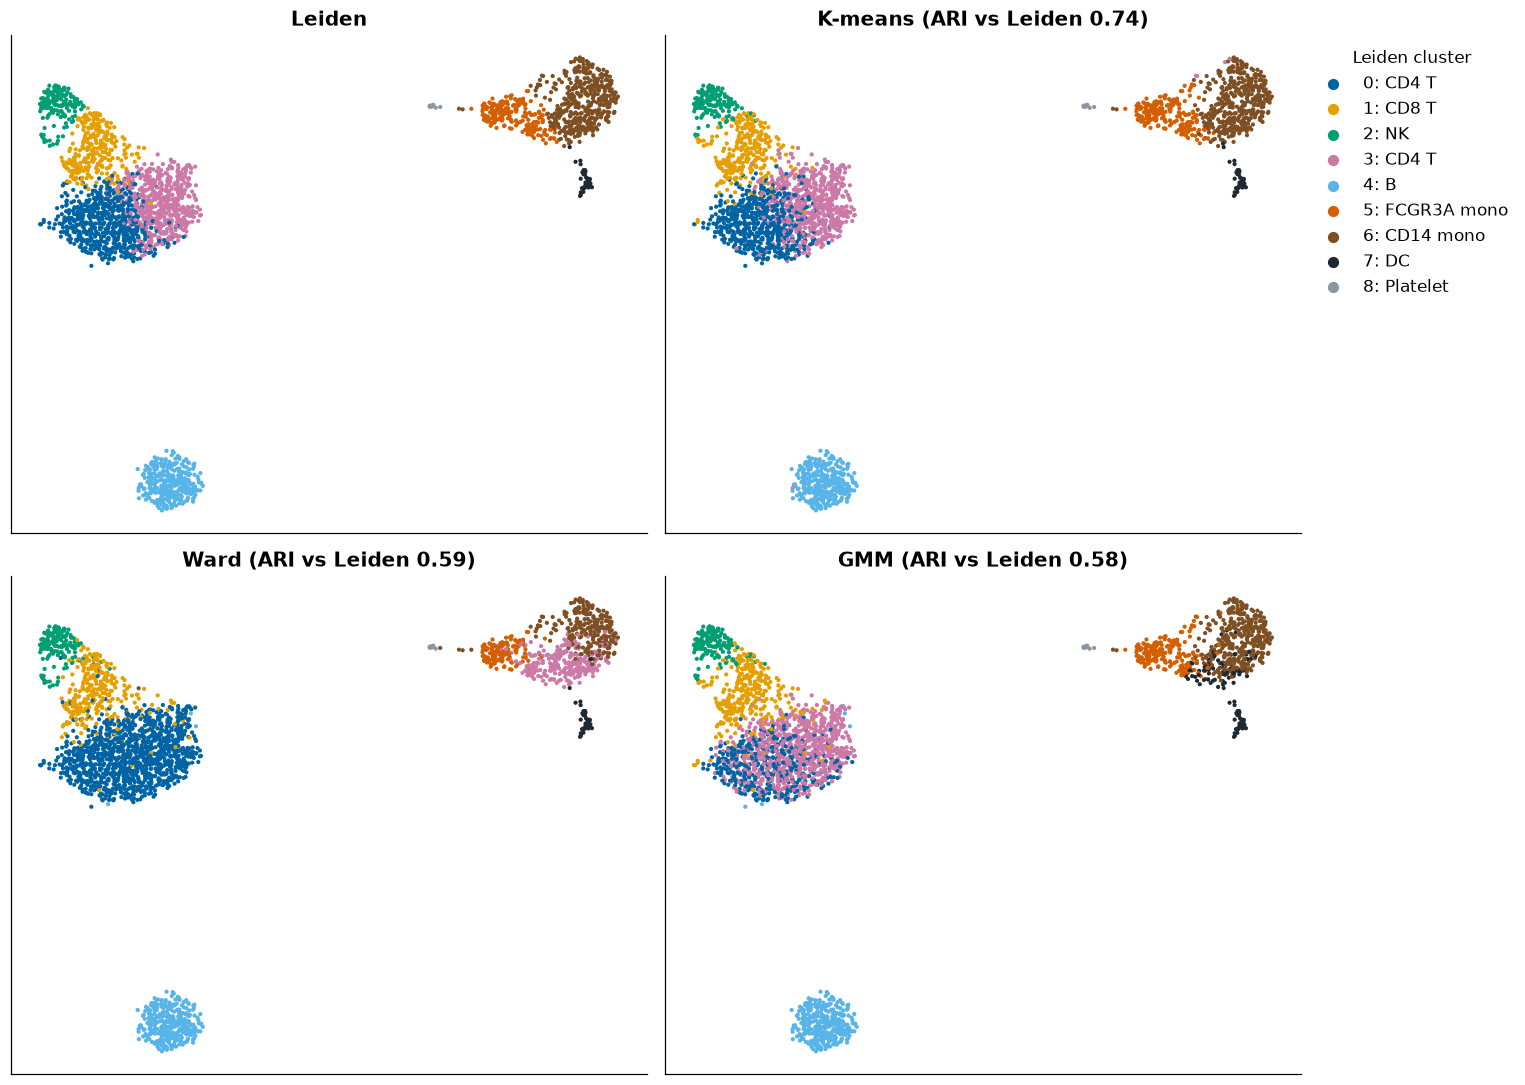

In [19]:
import umap
U = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit_transform(Xp)


def match_to(ref, lab):
    C = np.zeros((lab.max() + 1, ref.max() + 1))
    np.add.at(C, (lab, ref), 1)
    r_, c_ = linear_sum_assignment(-C)
    mp = dict(zip(r_, c_))
    return np.array([mp.get(v, ref.max() + 1 + v) for v in lab])


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, nm in zip(axes.ravel(), names):
    lab_ = leiden if nm == "Leiden" else match_to(leiden, labs[nm])
    ax.scatter(*U.T, s=3, c=[KCOL[c % len(KCOL)] for c in lab_])
    ax.set(title=f"{nm}" + ("" if nm == "Leiden" else f" (ARI vs Leiden {ARI.loc['Leiden', nm]:.2f})"),
           xticks=[], yticks=[])
for c in range(K):
    axes[0, 1].scatter([], [], s=40, color=KCOL[c], label=f"{c}: {mapping[c]}")
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), title="Leiden cluster")
plt.tight_layout(); plt.show()

Disagreements sit at borders: the two CD4 T groups and CD8 T vs NK.

### Evaluation: can internal scores choose K here?

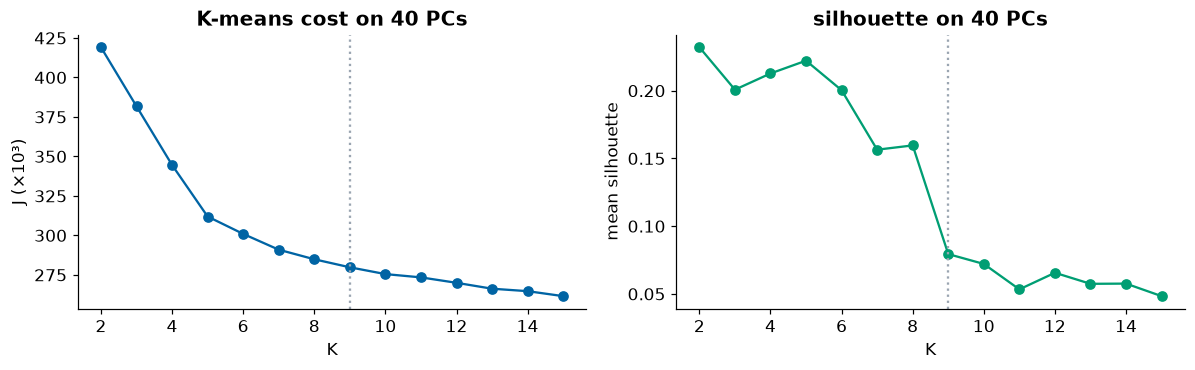

silhouette peaks at K = 2 (dotted line: Leiden's K = 9)


In [20]:
Ksp = np.arange(2, 16)
Jp, silp = [], []
for k in Ksp:
    km = KMeans(k, n_init=10, random_state=0).fit(Xp)
    Jp.append(km.inertia_); silp.append(silhouette_score(Xp, km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(Ksp, np.array(Jp) / 1e3, "o-"); axes[0].set(ylabel="J (×10³)", title="K-means cost on 40 PCs")
axes[1].plot(Ksp, silp, "o-", color=P[2]); axes[1].set(ylabel="mean silhouette", title="silhouette on 40 PCs")
for ax in axes:
    ax.set(xlabel="K"); ax.axvline(K, color=GREY, ls=":")
plt.tight_layout(); plt.show()
print(f"silhouette peaks at K = {Ksp[np.argmax(silp)]} (dotted line: Leiden's K = {K})")

No clear elbow, and the silhouette prefers a coarse split (lymphoid vs myeloid). Internal scores reward
well-separated groups; biologically meaningful cell types can be close neighbors. **K is chosen with biology
(distinct markers), not by a single score.**

## 7. Biological interpretation
- Four very different algorithms recover the same major blood cell types from 40 PCs of 1,838 genes, without any
  labels — this is how cell atlases are started. They disagree mainly on *resolution* (CD4 T naive vs memory) and at
  continuous borders (CD8 T vs NK).
- A cluster is a **hypothesis**: it becomes a cell type only when marker genes (and ideally function) support it.
  Rare types (13 platelets) are easy to lose with K-means, which prefers balanced clusters.
- Always check technical covariates (% mitochondrial counts, total counts) per cluster before naming it: two clusters
  that differ only in mitochondrial genes are more likely damaged cells than a new cell type.
- Cluster agreement (ARI/NMI) with reference labels measures consistency with earlier annotations, not truth.

In [21]:
print(f"total runtime: {time.time() - T0:.0f} s")

total runtime: 83 s


## 8. Try it yourself
The helper below reruns the PBMC pipeline with other settings and compares the result with the default Leiden
clustering (`ctype` = our cell-type labels).

In [22]:
def recluster(resolution=1.0, n_pcs=40, log1p=True, kmeans_K=None):
    a = adata.copy() if log1p else preprocess(log1p=False, genes=adata.var_names)
    sc.pp.neighbors(a, n_neighbors=10, n_pcs=n_pcs, random_state=0)
    sc.tl.leiden(a, resolution=resolution, random_state=0, flavor="igraph", n_iterations=2, directed=False)
    lei = a.obs.leiden.astype(int).values
    mp = annotate(a, lei)
    Xq = a.obsm["X_pca"][:, :n_pcs].astype(np.float64)
    km = KMeans(kmeans_K or lei.max() + 1, n_init=20, random_state=0).fit_predict(Xq)
    print(f"resolution {resolution}, {n_pcs} PCs, log1p={log1p}: Leiden K = {lei.max() + 1}; "
          f"ARI Leiden–K-means {ari(lei, km):.2f}; ARI vs default Leiden {ari(leiden, lei):.2f}, "
          f"K-means vs default cell types {ari(ctype, km):.2f}")
    print("  Leiden clusters named CD4 T:", sum(v == "CD4 T" for v in mp.values()), "| clusters:",
          ", ".join(f"{c}: {mp[c]} ({n_})" for c, n_ in enumerate(np.bincount(lei))))
    return a, lei, km


# example: _ = recluster(resolution=0.5)

1. Change the Leiden resolution. When do CD4 T cells split? (Try `recluster(resolution=r)` for r = 0.2, 0.4, 0.6,
   0.8, 1.0; or edit `RESOLUTION` in section 6 and rerun.)
2. Cluster on 10 vs. 40 PCs. Does ARI change? (`recluster(n_pcs=10)`, or edit `N_PCS`.)
3. Skip log1p. What do K-means clusters capture? (`a, lei, km = recluster(log1p=False)`, then compare
   `a.obs.total_counts` across the K-means clusters `km`.)
4. Run our from-scratch `kmeans(Xp, K, "kmeans++", rng)` on the 40 PCs 20 times and keep the lowest $J$. Does it
   match scikit-learn's inertia and labels (ARI)?
5. Replace K-means by the GMM in the restart experiment of section 2: how often does a single random GMM start end
   at the best log-likelihood?
6. *(CS284A)* Show numerically that EM approaches K-means as $\sigma\to0$: run EM with $\boldsymbol\Sigma_k=\sigma^2\mathbf I$
   fixed and $\pi_k=1/K$ on the 3-blob data for σ = 1, 0.3, 0.1 and compare the final assignments with K-means from the
   same starting centers.